# Customer Segmentation Analysis

This notebook demonstrates the end-to-end pipeline for customer segmentation using K-Means clustering. It covers data loading, preprocessing, scaling, model training, and visualizations.

In [1]:
# Setup imports and sys.path so we can import from src/
import os
import sys

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.append(repo_root)

from src.data_loader import load_data
from src.preprocessing import preprocess
from src.clustering_model import scale_features, compute_wcss, train_kmeans
from src.visualization import plot_income_vs_spending, plot_pairplot, plot_cluster_distribution

# Load data
raw_df = load_data(os.path.join(repo_root, "data", "mall_customers.csv"))

raw_df.head()


=== Dataset Summary ===
Shape: (50, 5)

First 5 rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              50 non-null     int64 
 1   Gender                  50 non-null     object
 2   Age                     50 non-null     int64 
 3   Annual Income (k$)      50 non-null     int64 
 4   Spending Score (1-100)  50 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 2.1+

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
# Preprocess and scale
clean_df = preprocess(raw_df)
scaled_df, scaler = scale_features(clean_df)

clean_df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


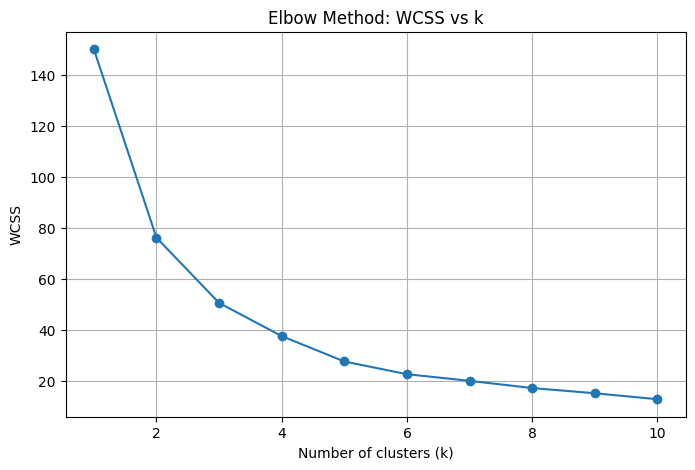

In [3]:
# Determine optimal number of clusters via the Elbow method
k_values = list(range(1, 11))
wcss = compute_wcss(scaled_df, k_values)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(k_values, wcss, marker="o")
plt.title("Elbow Method: WCSS vs k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [4]:
import pandas as pd

# Train KMeans and visualize clusters
k = 5
kmeans = train_kmeans(scaled_df, n_clusters=k)
clustered_df = clean_df.copy()
clustered_df["Cluster"] = kmeans.labels_

# Save visualizations to outputs/charts
plot_income_vs_spending(clustered_df, centroids=pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=clean_df.columns))
plot_pairplot(clustered_df)
plot_cluster_distribution(clustered_df)

clustered_df.head()

c:\Users\kodip\Documents\projects\prj-02\Customer_Segmentation_KMeans\src\visualization.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="tab10")


,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,19,15,39,4
1,21,15,81,0
2,20,16,6,4
3,23,16,77,0
4,31,17,40,4
